# ============================================================
# AIML505 Project
# Group F
# Temporal GNNs for Dhaka Stock Exchange Price Forecasting
# Part 1 : Data Loading & Cleaning
# ============================================================

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from scipy import stats

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

## data loading

In [2]:
DATA_PATH = "./Dataset/raw/DSE_Data.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)

df.head()

(1523921, 7)


,Trading_Code,Date,Open,High,Low,Close,Volume
0,SIBL,2025-04-08,9.9,10.0,9.8,9.9,359773.0
1,MEGHNALIFE,2025-04-08,54.5,56.6,54.1,56.1,610711.0
2,BPML,2025-04-08,41.1,41.7,40.0,40.2,482031.0
3,CROWNCEMNT,2025-04-08,47.9,50.9,47.5,50.0,104860.0
4,ATCSLGF,2025-04-08,0.0,0.0,0.0,7.5,0.0


In [3]:
print(df.info())

print(df.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1523921 entries, 0 to 1523920
Data columns (total 7 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   Trading_Code  1523921 non-null  object 
 1   Date          1523921 non-null  object 
 2   Open          1523921 non-null  float64
 3   High          1523921 non-null  float64
 4   Low           1523921 non-null  float64
 5   Close         1523921 non-null  float64
 6   Volume        1523919 non-null  float64
dtypes: float64(5), object(2)
memory usage: 81.4+ MB
None
       Trading_Code        Date          Open          High           Low  \
count       1523921     1523921  1.523921e+06  1.523921e+06  1.523921e+06   
unique          534        6429           NaN           NaN           NaN   
top             ACI  2022-08-03           NaN           NaN           NaN   
freq           6585        1151           NaN           NaN           NaN   
mean            NaN         NaN  2.57552

### Duplicate Check of df

In [4]:
# Preserve original row number
df = df.reset_index().rename(columns={"index": "Row_Number"})

# Find all duplicates based on Trading_Code and Date
duplicates = df[
    df.duplicated(
        subset=["Trading_Code", "Date"],
        keep=False
    )
].sort_values(["Trading_Code", "Date"])

print(f"Total duplicate rows: {len(duplicates)}")
print(f"Duplicate groups: {duplicates.groupby(['Trading_Code','Date']).ngroups}")

duplicates.head(20)

Total duplicate rows: 132641
Duplicate groups: 63902


,Row_Number,Trading_Code,Date,Open,High,Low,Close,Volume
1129121,1129121,1JANATAMF,2012-01-10,8.0,8.8,8.0,8.6,1536500.0
1129126,1129126,1JANATAMF,2012-01-10,8.0,8.8,8.0,8.6,1536500.0
330519,330519,1JANATAMF,2022-07-18,6.3,6.3,6.2,6.3,313622.0
331038,331038,1JANATAMF,2022-07-18,6.3,6.3,6.2,6.3,313622.0
329753,329753,1JANATAMF,2022-07-19,6.2,6.2,6.2,6.2,241252.0
330136,330136,1JANATAMF,2022-07-19,6.2,6.2,6.2,6.2,241252.0
328965,328965,1JANATAMF,2022-07-20,6.1,6.3,6.1,6.2,132657.0
329372,329372,1JANATAMF,2022-07-20,6.1,6.3,6.1,6.2,132657.0
328367,328367,1JANATAMF,2022-07-21,6.2,6.3,6.2,6.2,279669.0
328748,328748,1JANATAMF,2022-07-21,6.2,6.3,6.2,6.2,279669.0


In [5]:
duplicates.to_csv(
    "Dataset/modified/duplicate_tradingcode_date_records.csv",
    index=False
)

print("Saved: Dataset/modified/duplicate_tradingcode_date_records.csv")

Saved: Dataset/modified/duplicate_tradingcode_date_records.csv


#### Drop Duplicate

In [6]:
df_clean = df.drop_duplicates(
    subset=["Trading_Code", "Date"],
    keep="first"
)

In [7]:
print(f"Original rows: {len(df):,}")
print(f"Cleaned rows: {len(df_clean):,}")
print(f"Rows removed: {len(df)-len(df_clean):,}")
df = df_clean

Original rows: 1,523,921
Cleaned rows: 1,455,182
Rows removed: 68,739


In [8]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(["Trading_Code","Date"])

df.reset_index(drop=True, inplace=True)

In [9]:
total_companies = df['Trading_Code'].nunique()
print(f"Total unique companies in the dataset: {total_companies}")

Total unique companies in the dataset: 534


In [10]:
missing = df.isnull().sum()

missing

Row_Number      0
Trading_Code    0
Date            0
Open            0
High            0
Low             0
Close           0
Volume          2
dtype: int64

#### Drop rows with null Volume

In [11]:

df = df.dropna(subset=['Volume'])

## Sector info extraction

### Sector merging with missing info
#### Sector df1 a dataset of internet

In [12]:
sector_df1 = pd.read_csv("Dataset/modified/finance_sector_info.csv")
sector_df1 = sector_df1.rename(columns={'trading_code': 'Trading_Code'})
sector_df1.head()


unique_sectors1 = sector_df1['Sector'].dropna().unique()
print("Unique sectors in the completed dataset:")
print(sorted(unique_sectors1))
print("Number of unique sectors in the completed dataset:", len(unique_sectors1))

unique_companies1 = sector_df1['Trading_Code'].dropna().unique()
print("Unique companies in the completed dataset:")
print(unique_companies1.size)

Unique sectors in the completed dataset:
['Bank', 'Cement', 'Ceramics', 'Engineering', 'Financial Institutions', 'Food&Allied', 'ITSector', 'Insurance', 'Jute', 'Miscellaneous', 'MutualFunds', 'PaperPrint', 'Pharmaceuticals&Chemicals', 'Power&Fuel', 'Services & Real Estate', 'Tannery Industries', 'Telecommunication', 'Textile', 'Travel&Lesiure']
Number of unique sectors in the completed dataset: 19
Unique companies in the completed dataset:
474


#### Extracted missing sectors and manually filled them

In [13]:
sector_df2 = pd.read_csv("Dataset/modified/unique_null_sectors_completed.csv")

sector_df2.head()

unique_sectors2 = sector_df2['Sector'].dropna().unique()
print("Unique sectors in the completed dataset:")
print(sorted(unique_sectors2))
print("Number of unique sectors in the completed dataset:", len(unique_sectors2))

unique_companies2 = sector_df2['Trading_Code'].dropna().unique()
print("Unique companies in the completed dataset:")
print(unique_companies2.size)

Unique sectors in the completed dataset:
['Bank', 'Cement', 'Ceramics', 'Corporate Bond', 'Debenture', 'Engineering', 'Financial Institutions', 'Food&Allied', 'ITSector', 'Index', 'Insurance', 'Jute', 'Miscellaneous', 'MutualFunds', 'PaperPrint', 'Pharmaceuticals&Chemicals', 'Power&Fuel', 'Tannery Industries', 'Telecommunication', 'Textile', 'Travel&Lesiure']
Number of unique sectors in the completed dataset: 21
Unique companies in the completed dataset:
154


#### Concat the two df to make a copleate list of dse companies

In [14]:
sector_cat = pd.concat([sector_df1, sector_df2], ignore_index=True)

unique_sectors3 = sector_cat['Sector'].dropna().unique()
print("Unique sectors in the completed dataset:")
print(sorted(unique_sectors3))
print("Number of unique sectors in the completed dataset:", len(unique_sectors3))

unique_companies3 = sector_cat['Trading_Code'].dropna().unique()
print("Unique companies in the completed dataset:")
print(unique_companies3.size)

Unique sectors in the completed dataset:
['Bank', 'Cement', 'Ceramics', 'Corporate Bond', 'Debenture', 'Engineering', 'Financial Institutions', 'Food&Allied', 'ITSector', 'Index', 'Insurance', 'Jute', 'Miscellaneous', 'MutualFunds', 'PaperPrint', 'Pharmaceuticals&Chemicals', 'Power&Fuel', 'Services & Real Estate', 'Tannery Industries', 'Telecommunication', 'Textile', 'Travel&Lesiure']
Number of unique sectors in the completed dataset: 22
Unique companies in the completed dataset:
628


### Merge with df

In [15]:
merge = pd.merge(sector_cat, df, left_on='Trading_Code', right_on='Trading_Code', how='right')
merge.head()

,Trading_Code,Sector,Row_Number,Date,Open,High,Low,Close,Volume
0,1JANATAMF,MutualFunds,1245058,2010-01-11,10.6,10.8,10.4,10.5,794000.0
1,1JANATAMF,MutualFunds,1244614,2010-01-12,10.1,10.3,10.0,10.1,772000.0
2,1JANATAMF,MutualFunds,1239975,2010-02-11,10.7,10.7,10.3,10.4,781500.0
3,1JANATAMF,MutualFunds,1239838,2010-02-12,10.1,10.2,9.9,9.9,808500.0
4,1JANATAMF,MutualFunds,1235802,2010-03-10,12.4,12.5,11.8,11.8,1189500.0


In [16]:
#unique companies after dropping rows with null Volume
unique_trading_codes = merge['Trading_Code'].nunique()
print(f"Unique trading codes in the dataset: {unique_trading_codes}")

Unique trading codes in the dataset: 534


#### replacing df with new merged df

In [17]:
df = merge

### Null check

In [18]:
missing_percent = (
    df.isnull()
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

missing_percent

Sector          0.01
Trading_Code    0.00
Row_Number      0.00
Date            0.00
Open            0.00
High            0.00
Low             0.00
Close           0.00
Volume          0.00
dtype: float64

#### Companies that are missing Sector info

In [19]:
# show the missing sector information unique companies 
missing_sector_companies = df[df['Sector'].isnull()]['Trading_Code'].unique()
print("Unique companies with missing sector information:")
print(missing_sector_companies)

Unique companies with missing sector information:
['BLTC' 'FUWANGCER ']


#### Droping two companins without sector info

In [20]:
df = df.dropna(subset=['Sector'])
missing_sector_companies = df[df['Sector'].isnull()]['Trading_Code'].unique()
print("Unique companies with missing sector information:")
print(missing_sector_companies)

Unique companies with missing sector information:
[]


### Plot

In [21]:
missing_percent = (
    df.isnull()
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

missing_percent

Trading_Code    0.0
Sector          0.0
Row_Number      0.0
Date            0.0
Open            0.0
High            0.0
Low             0.0
Close           0.0
Volume          0.0
dtype: float64

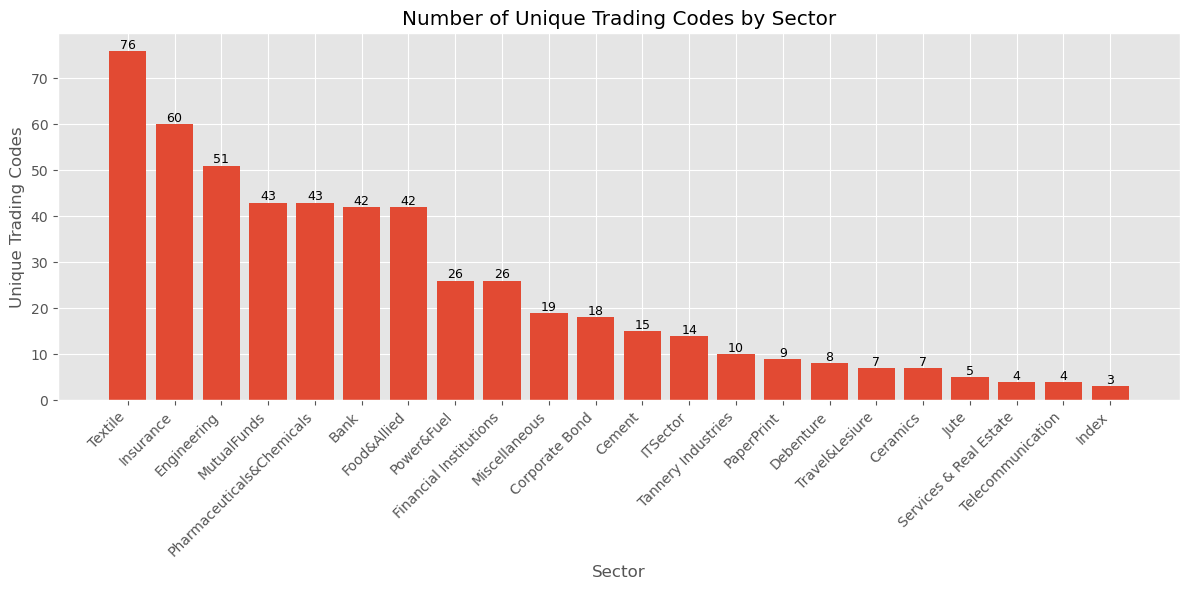

In [22]:

# Count unique Trading_Code per Sector
sector_counts = (
    df[['Trading_Code', 'Sector']]
    .drop_duplicates(subset='Trading_Code')   # Count each Trading_Code only once
    .fillna({'Sector': 'Missing'})
    .groupby('Sector')['Trading_Code']
    .count()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
plt.bar(sector_counts.index, sector_counts.values)

plt.title("Number of Unique Trading Codes by Sector")
plt.xlabel("Sector")
plt.ylabel("Unique Trading Codes")

plt.xticks(rotation=45, ha='right')

# Add value labels
for i, v in enumerate(sector_counts.values):
    plt.text(i, v + 0.5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

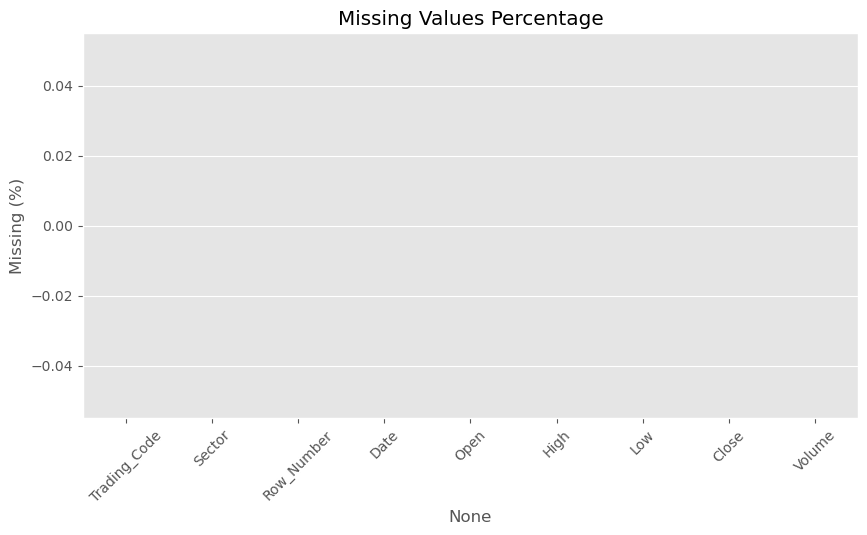

In [23]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=missing_percent.index,
    y=missing_percent.values
)

plt.xticks(rotation=45)
plt.ylabel("Missing (%)")
plt.title("Missing Values Percentage")

plt.show()

In [24]:
duplicate_rows = df.duplicated()

print("Duplicate Rows :", duplicate_rows.sum())

Duplicate Rows : 0


In [25]:
print("Number of Companies :", df["Trading_Code"].nunique())

Number of Companies : 532


In [26]:
print(df["Sector"].nunique())
#sorted unique sectors

print(sorted(df["Sector"].unique()))

22
['Bank', 'Cement', 'Ceramics', 'Corporate Bond', 'Debenture', 'Engineering', 'Financial Institutions', 'Food&Allied', 'ITSector', 'Index', 'Insurance', 'Jute', 'Miscellaneous', 'MutualFunds', 'PaperPrint', 'Pharmaceuticals&Chemicals', 'Power&Fuel', 'Services & Real Estate', 'Tannery Industries', 'Telecommunication', 'Textile', 'Travel&Lesiure']


In [27]:
print("Start :", df["Date"].min())

print("End   :", df["Date"].max())

print("Days  :", df["Date"].nunique())

Start : 1999-01-02 00:00:00
End   : 2025-04-08 00:00:00
Days  : 6429


In [28]:
price_cols = [
    "Open",
    "High",
    "Low",
    "Close"
]

df[price_cols].describe()

,Open,High,Low,Close
count,1.454978e+06,1.454978e+06,1.454978e+06,1.454978e+06
mean,2.627659e+02,2.666455e+02,2.586915e+02,8.313604e+02
std,1.180895e+03,1.187138e+03,1.174308e+03,2.377076e+04
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.800000e+01,1.830000e+01,1.770000e+01,1.870000e+01
50%,4.480000e+01,4.550000e+01,4.400000e+01,4.610000e+01
75%,1.791000e+02,1.820000e+02,1.762000e+02,1.886000e+02
max,1.037500e+06,1.037500e+06,1.037500e+06,1.037500e+06


In [29]:
df = df[
    (df["Open"] > 0) &
    (df["High"] > 0) &
    (df["Low"] > 0) &
    (df["Close"] > 0)
]

In [30]:
invalid = df[
    (df["High"] < df["Low"]) |
    (df["High"] < df["Open"]) |
    (df["High"] < df["Close"])
]
print(invalid)
# number of invalid rows
print(f"Number of invalid rows: {invalid.shape[0]}")
# invalid.to_csv(
#     "Dataset/modified/invalid_price_records.csv",
#     index=False
# )
# print("Saved: Dataset/modified/invalid_price_records.csv")

        Trading_Code                     Sector  Row_Number       Date  \
58883     AIBL1STIMF                MutualFunds      937766 2014-12-15   
81480         ALLTEX                    Textile      710445 2017-11-14   
101256    ANLIMAYARN                    Textile      937828 2014-12-15   
171761     AZIZPIPES                Engineering      937730 2014-12-15   
240906     BDWELDING                 Power&Fuel      937753 2014-12-15   
368194           DBH     Financial Institutions      680269 2018-03-27   
409772          DSES                      Index     1003957 2014-01-04   
412504          DSEX                      Index      748246 2017-05-29   
414192      DSHGARME                    Textile     1207743 2010-08-31   
463297           EHL     Services & Real Estate     1236179 2010-03-08   
479978     EXIM1STMF                MutualFunds      937637 2014-12-15   
503217         FBFIF                MutualFunds      937825 2014-12-15   
546616       GENNEXT                  

In [31]:
df = df.drop(invalid.index)
invalid = df[
    (df["High"] < df["Low"]) |
    (df["High"] < df["Open"]) |
    (df["High"] < df["Close"])
]
print(invalid)
# number of invalid rows
print(f"Number of invalid rows: {invalid.shape[0]}")

Empty DataFrame
Columns: [Trading_Code, Sector, Row_Number, Date, Open, High, Low, Close, Volume]
Index: []
Number of invalid rows: 0


In [32]:
df["Return"] = (
    df.groupby("Trading_Code")["Close"]
      .pct_change()
)

df["Log_Return"] = np.log(
    df["Close"] /
    df.groupby("Trading_Code")["Close"].shift(1)
)

In [33]:
df["MA_7"] = (
    df.groupby("Trading_Code")["Close"]
      .transform(lambda x: x.rolling(7).mean())
)

df["MA_30"] = (
    df.groupby("Trading_Code")["Close"]
      .transform(lambda x: x.rolling(30).mean())
)

In [34]:
df["Volatility_30"] = (
    df.groupby("Trading_Code")["Return"]
      .transform(lambda x: x.rolling(30).std())
)

In [35]:
print(df.info())

print(df.head())


<class 'pandas.core.frame.DataFrame'>
Index: 1432935 entries, 0 to 1455179
Data columns (total 14 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Trading_Code   1432935 non-null  object        
 1   Sector         1432935 non-null  object        
 2   Row_Number     1432935 non-null  int64         
 3   Date           1432935 non-null  datetime64[ns]
 4   Open           1432935 non-null  float64       
 5   High           1432935 non-null  float64       
 6   Low            1432935 non-null  float64       
 7   Close          1432935 non-null  float64       
 8   Volume         1432935 non-null  float64       
 9   Return         1432412 non-null  float64       
 10  Log_Return     1432412 non-null  float64       
 11  MA_7           1429836 non-null  float64       
 12  MA_30          1418090 non-null  float64       
 13  Volatility_30  1417581 non-null  float64       
dtypes: datetime64[ns](1), float64(10), int6

## Save the cleaned dataset to a new CSV file

In [36]:
df.to_csv("Dataset/modified/cleaned_dse_data.csv", index=False)

print("Saved: Dataset/modified/cleaned_dse_data.csv")

Saved: Dataset/modified/cleaned_dse_data.csv


# EDA


In [37]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

print(df.columns)

Rows : 1432935
Columns : 14
Index(['Trading_Code', 'Sector', 'Row_Number', 'Date', 'Open', 'High', 'Low',
       'Close', 'Volume', 'Return', 'Log_Return', 'MA_7', 'MA_30',
       'Volatility_30'],
      dtype='object')


In [38]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Row_Number,1432935.0,795454.282761,0.0,448700.5,806947.0,1165478.5,1523920.0,431692.198962
Date,1432935,2015-11-16 19:31:17.740163072,1999-01-02 00:00:00,2011-05-31 00:00:00,2016-08-31 00:00:00,2021-02-24 00:00:00,2025-04-08 00:00:00,NaN
Open,1432935.0,266.790448,0.67,18.8,46.0,184.0,1037500.0,1189.475028
High,1432935.0,270.729998,0.67,19.1,46.9,187.0,1037500.0,1195.754498
Low,1432935.0,262.653661,0.67,18.4,45.1,181.0,1037500.0,1182.848448
Close,1432935.0,266.203433,0.67,18.7,45.9,183.5,1037500.0,1188.595043
Volume,1432935.0,694691.029599,0.0,7280.0,63211.0,324900.0,295392690.0,5549305.18434
Return,1432412.0,0.017081,-0.997951,-0.022184,0.0,0.020079,487.0,0.719615
Log_Return,1432412.0,-0.000262,-6.190572,-0.022434,0.0,0.01988,6.190315,0.162585
MA_7,1429836.0,265.506389,0.68,18.9,46.271429,187.107143,38123.107143,803.235909


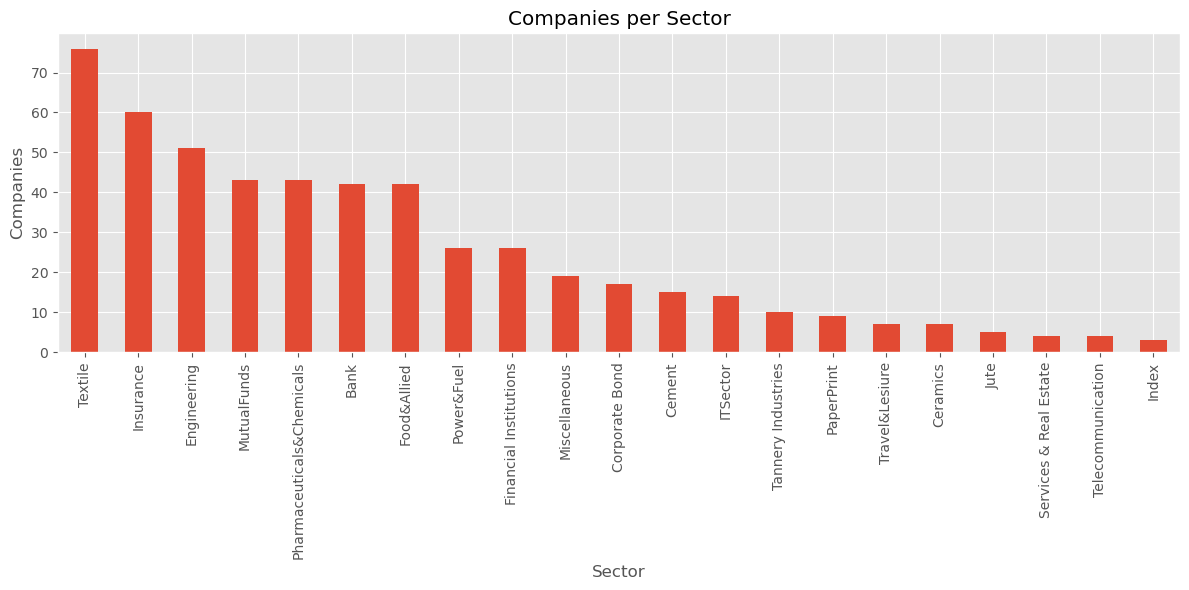

In [39]:
sector_count = (
    df.groupby("Sector")["Trading_Code"]
      .nunique()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sector_count.plot(kind="bar")

plt.ylabel("Companies")

plt.title("Companies per Sector")

plt.tight_layout()

plt.show()

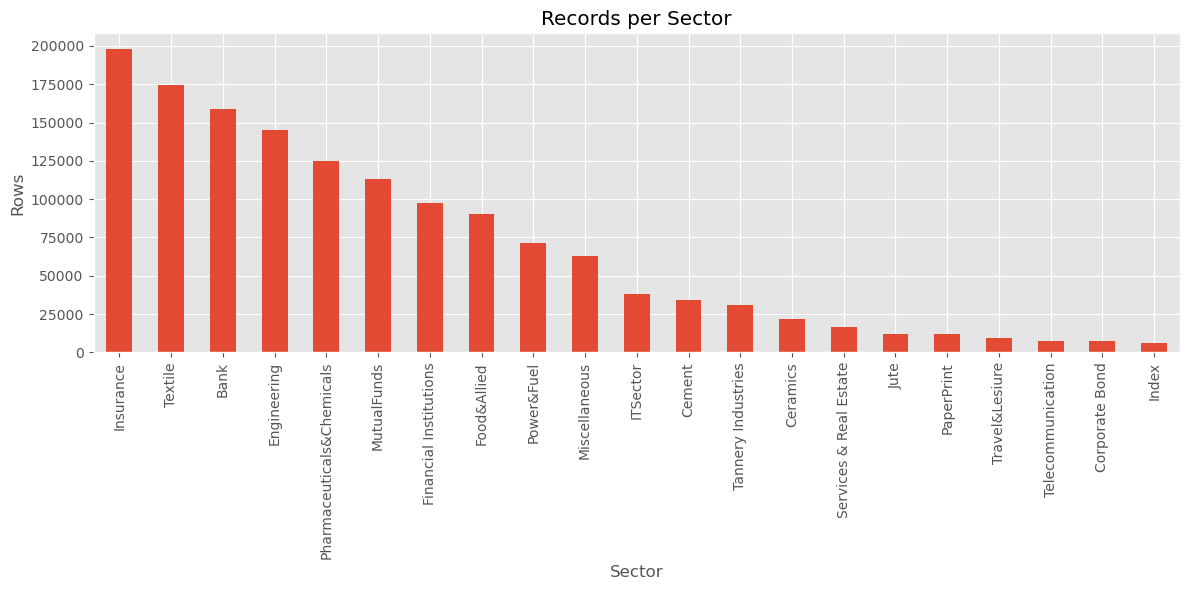

In [40]:
records = (
    df.groupby("Sector")
      .size()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

records.plot(kind="bar")

plt.ylabel("Rows")

plt.title("Records per Sector")

plt.tight_layout()

plt.show()

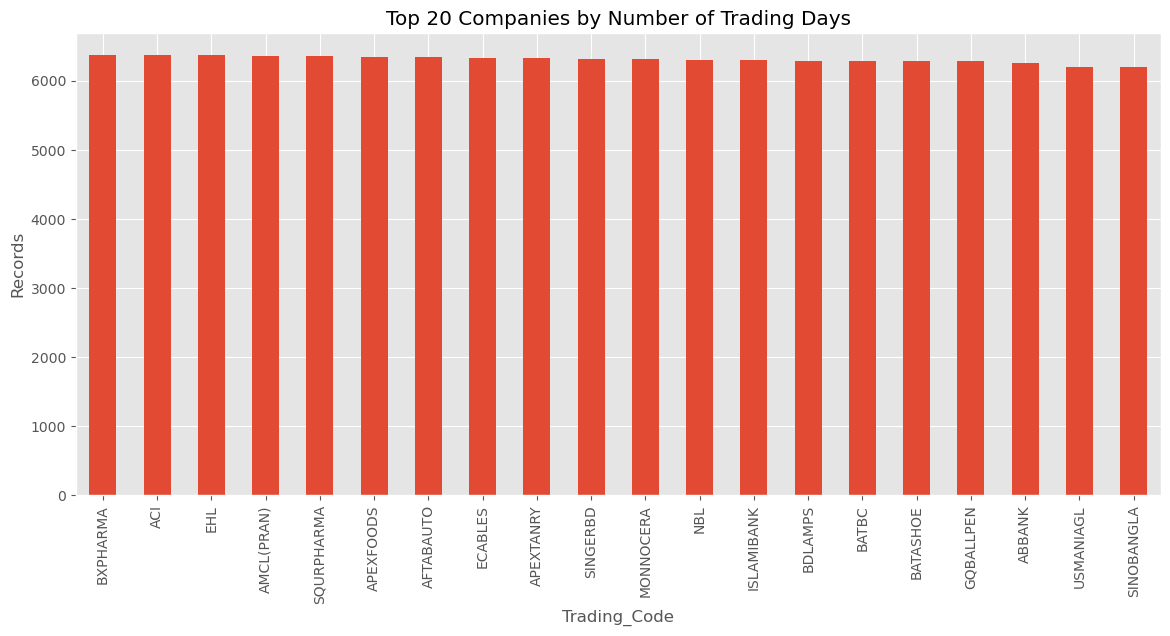

In [41]:
top_stock = (
    df["Trading_Code"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(14,6))

top_stock.plot(kind="bar")

plt.ylabel("Records")

plt.title("Top 20 Companies by Number of Trading Days")

plt.show()

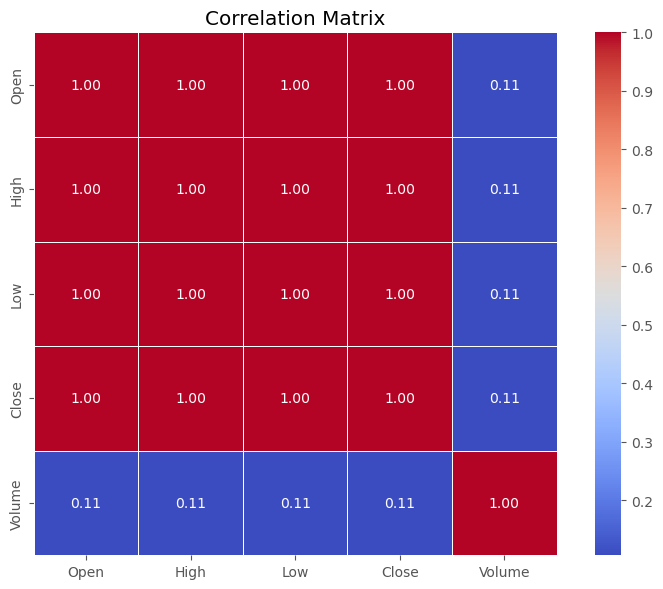

In [42]:
# Correlation Matrix

columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

corr = df[columns].corr(numeric_only=True)

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

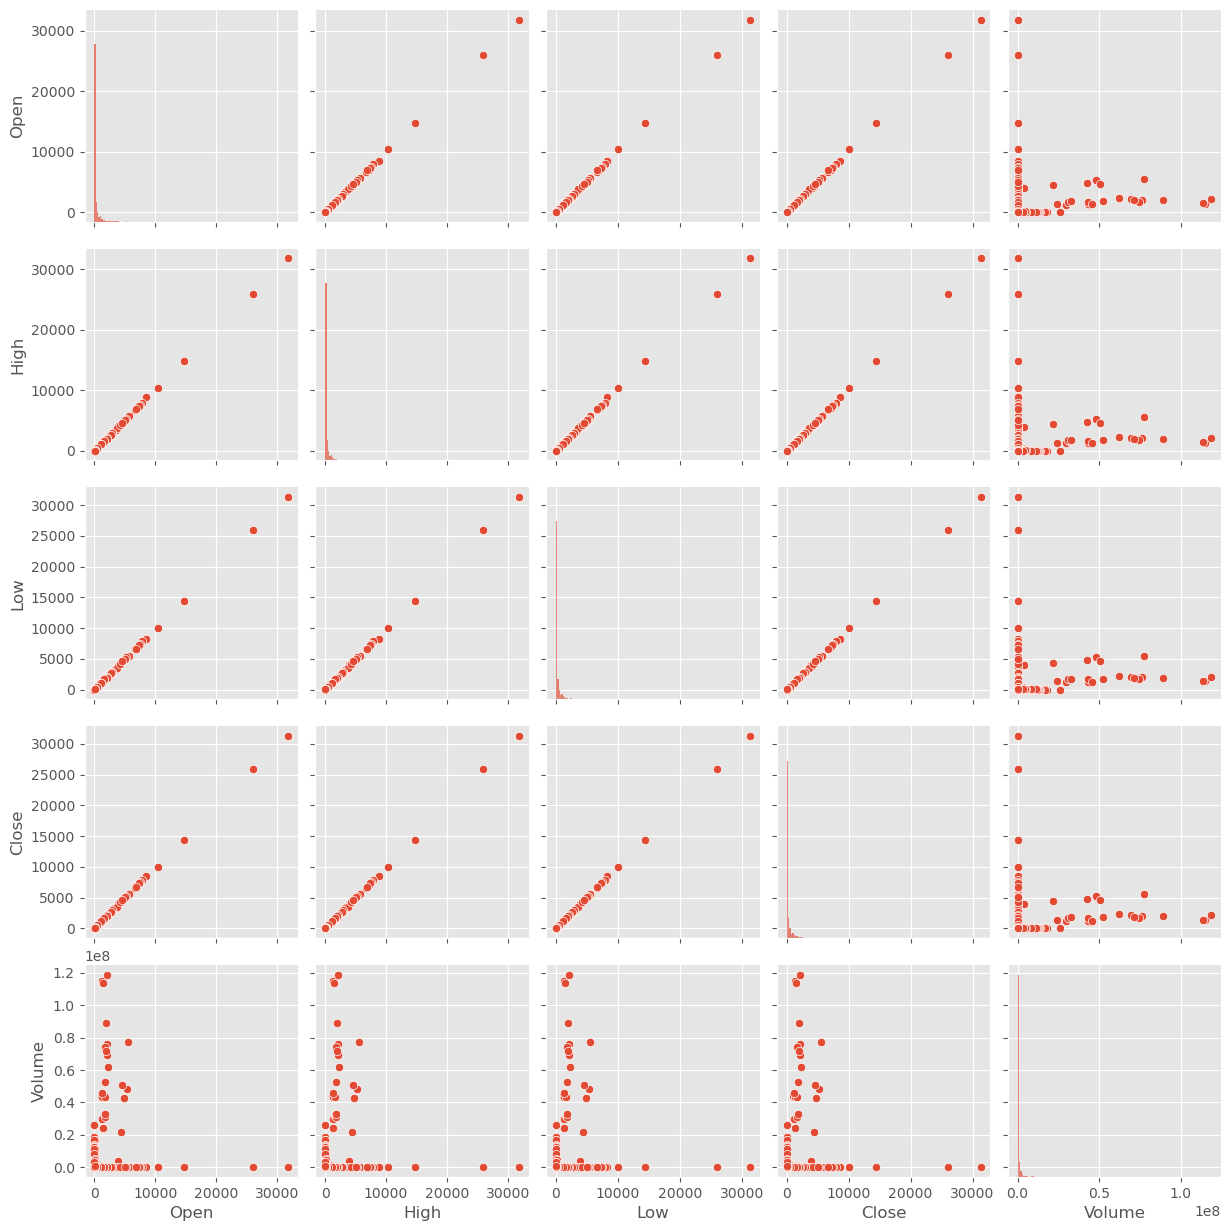

In [43]:
sample = df.sample(5000, random_state=42)

sns.pairplot(
    sample[
        ["Open","High","Low","Close","Volume"]
    ]
)

plt.show()

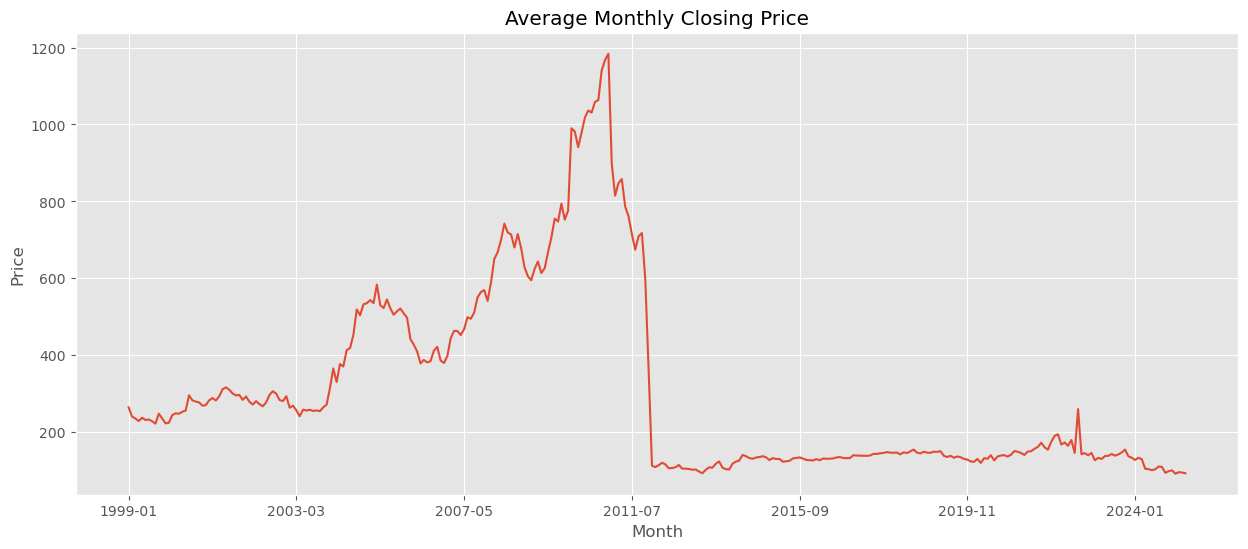

In [44]:
monthly = df.copy()

monthly["Month"] = monthly["Date"].dt.to_period("M")

monthly = (
    monthly.groupby("Month")["Close"]
           .mean()
)

monthly.index = monthly.index.astype(str)

plt.figure(figsize=(15,6))

monthly.plot()

plt.title("Average Monthly Closing Price")

plt.ylabel("Price")

plt.show()

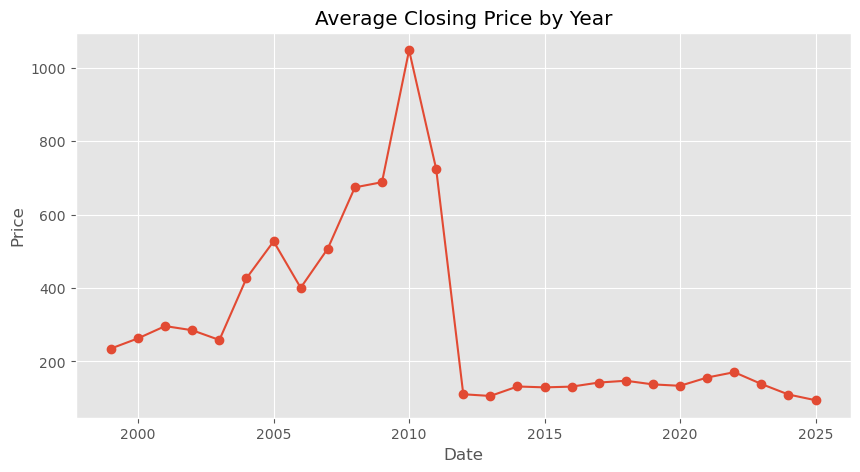

In [45]:
yearly = (
    df.groupby(df["Date"].dt.year)["Close"]
      .mean()
)

plt.figure(figsize=(10,5))

yearly.plot(marker="o")

plt.title("Average Closing Price by Year")

plt.ylabel("Price")

plt.show()

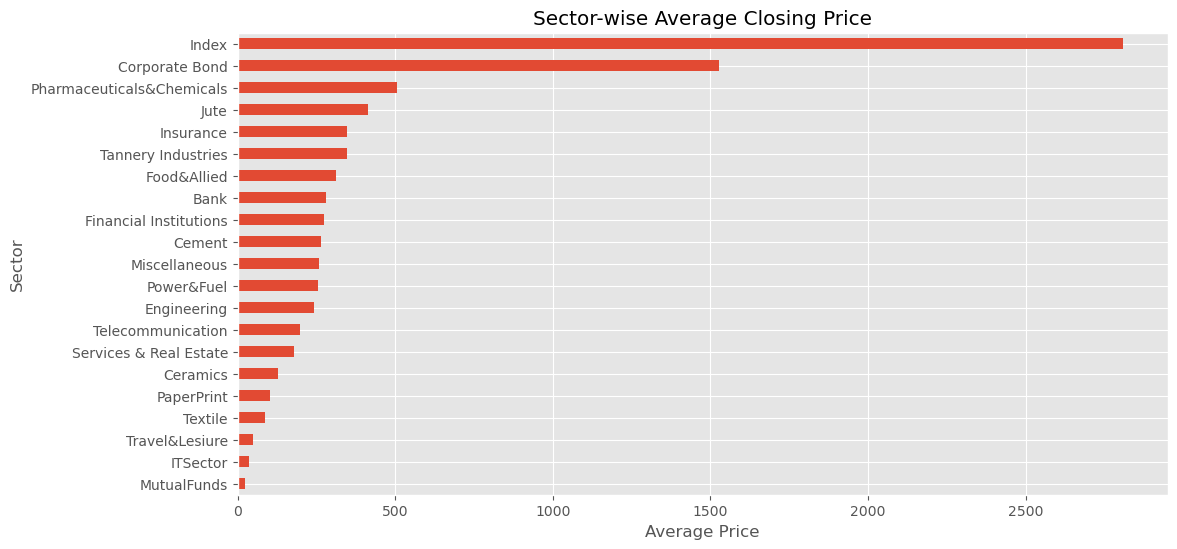

In [46]:
sector_price = (
    df.groupby("Sector")["Close"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(12,6))

sector_price.plot(kind="barh")

plt.xlabel("Average Price")

plt.title("Sector-wise Average Closing Price")

plt.show()

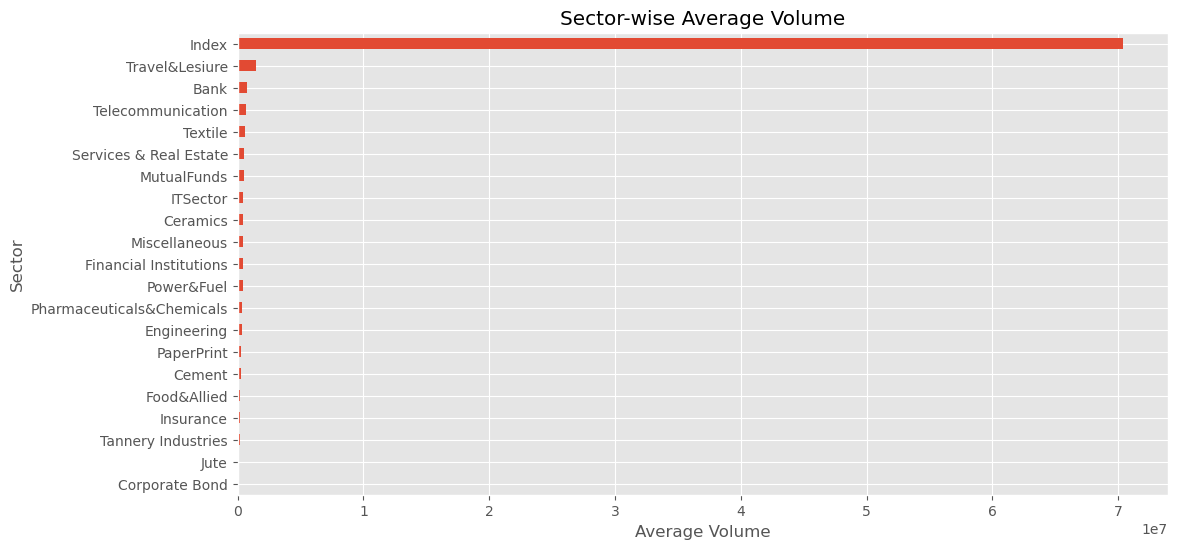

In [47]:
sector_volume = (
    df.groupby("Sector")["Volume"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(12,6))

sector_volume.plot(kind="barh")

plt.xlabel("Average Volume")

plt.title("Sector-wise Average Volume")

plt.show()

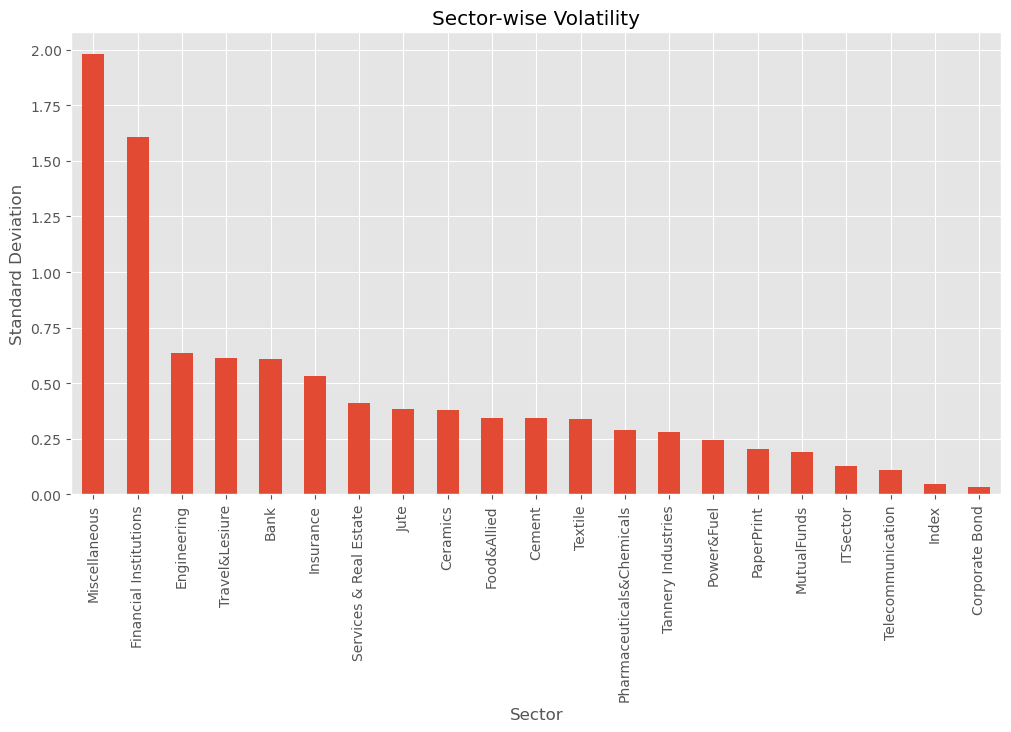

In [48]:
sector_volatility = (
    df.groupby("Sector")["Return"]
      .std()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sector_volatility.plot(kind="bar")

plt.ylabel("Standard Deviation")

plt.title("Sector-wise Volatility")

plt.show()

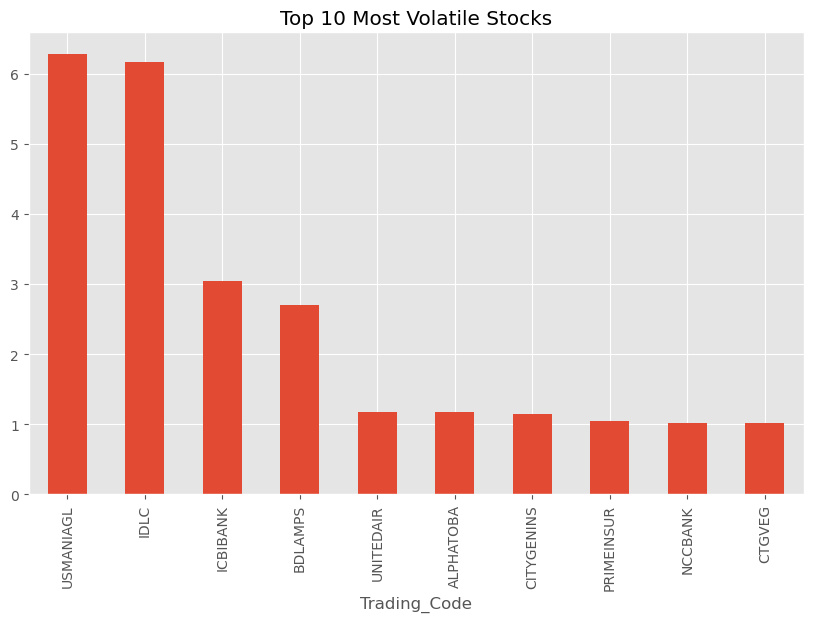

In [49]:
volatility = (
    df.groupby("Trading_Code")["Return"]
      .std()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

volatility.plot(kind="bar")

plt.title("Top 10 Most Volatile Stocks")

plt.show()

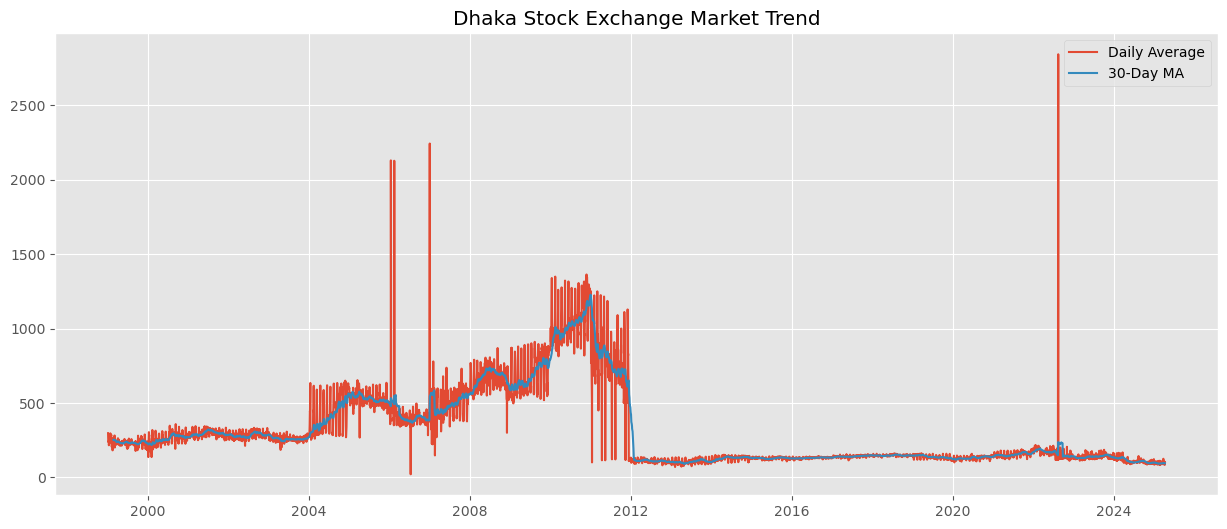

In [50]:
market = (
    df.groupby("Date")["Close"]
      .mean()
)

rolling = market.rolling(30).mean()

plt.figure(figsize=(15,6))

plt.plot(market,label="Daily Average")

plt.plot(rolling,label="30-Day MA")

plt.legend()

plt.title("Dhaka Stock Exchange Market Trend")

plt.show()

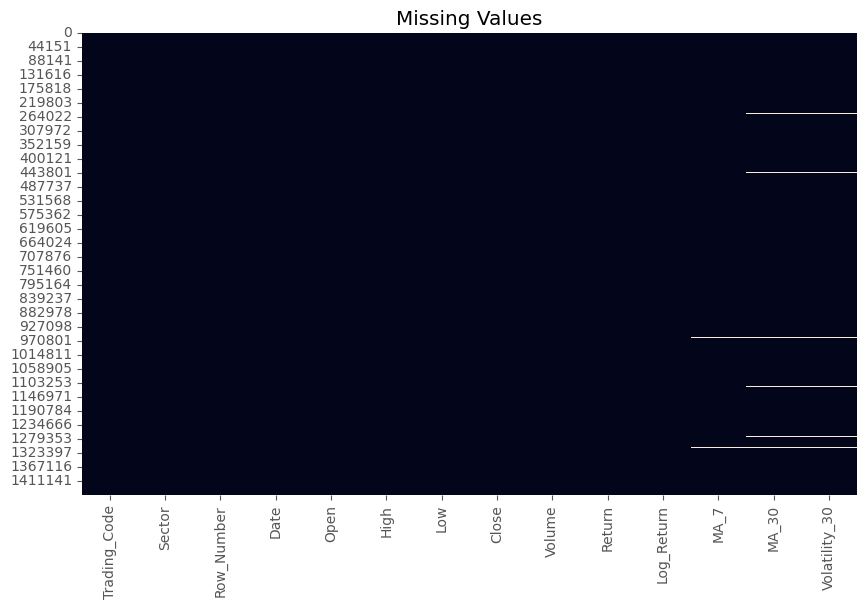

In [51]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values")

plt.show()